# Ecoregion, Land-Cover, and Spatial Smoothness Analysis

This notebook analyzes the **4-month test setting** (March, June, September, December) for Temporal Transformer, Presto, and Prithvi. Dense predictions are generated offline for seeds 42, 123, and 456 by `supportive-analysis/prepare_stratified_data.py`; this notebook reads compact tile-level tables and runs on CPU.

All MAE summaries are tile-year balanced: calculate a metric within each tile-year, average tile-years within each seed, then average the three seeds. This prevents large tiles or common pixel classes from dominating the result.

To rebuild the derived cache on a GPU node:

```bash
conda run -n geo python supportive-analysis/prepare_stratified_data.py \
  --seeds seed_42 seed_123 seed_456 \
  --out-dir data/stratified_analysis/m3-6-9-12
```

In [1]:
from pathlib import Path
import json
import sys
import textwrap

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "lib").exists():
    REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from shapely import make_valid
from shapely.geometry import box

from lib.stratified_analysis import summarize_seed_balanced

CACHE_DIR = Path("data/stratified_analysis/m3-6-9-12")
SMOOTH_DIR = Path("data/stratified_analysis/smoothness_metric_comparison")
TILE_DIR = Path("student_test_tiles_m3-6-9-12/data/m3-6-9-12/test")
IMAGE_DIR = Path("paper_latex/Images")
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ORDER = ["temporal_transformer", "presto", "prithvi"]
MODEL_LABELS = {
    "temporal_transformer": "Temporal Transformer",
    "presto": "Presto",
    "prithvi": "Prithvi",
}
MODEL_COLORS = dict(zip(MODEL_ORDER, sns.color_palette("Set2", 3)))
PHASE_ORDER = ["Greenup", "Maturity", "Senescence/Silking", "Dormancy/Dough"]
PHASE_LABELS = ["Greenup", "Maturity", "Senescence", "Dormancy"]

required = [
    "manifest.json", "ecoregion_tile_mae.csv", "landcover_tile_mae.csv",
    "smoothness_tile_phase.csv", "ecoregion_l1_us.geojson", "us_states.geojson",
]
missing = [name for name in required if not (CACHE_DIR / name).exists()]
assert not missing, f"Missing cache files: {missing}. Run the GPU cache builder first."
smooth_required = ["gt_smoothness_tertiles.csv", "mae_by_smoothness_tertile.csv"]
smooth_missing = [name for name in smooth_required if not (SMOOTH_DIR / name).exists()]
assert not smooth_missing, (
    f"Missing smoothness files: {smooth_missing}. Run "
    "supportive-analysis/evaluate_smoothness_metrics.py first."
)

manifest = json.loads((CACHE_DIR / "manifest.json").read_text())
assert manifest["n_tile_years"] == 48
assert manifest["seeds"] == ["seed_42", "seed_123", "seed_456"]
manifest

{'split': 'test',
 'selected_months': [3, 6, 9, 12],
 'n_tile_years': 48,
 'seeds': ['seed_42', 'seed_123', 'seed_456'],
 'models': ['temporal_transformer', 'presto', 'prithvi'],
 'checkpoints': {'seed_42': {'temporal_transformer': {'group': 'transformer_1d_paper_1.0',
    'seed': 'seed_42',
    'checkpoint': 'transformer_1d_paper_lr-0.0001_bs-1024_dm-64_nl-4_e-100_allpx_loss-mae_seed-42.pth'},
   'presto': {'group': 'presto_1.0',
    'seed': 'seed_42',
    'checkpoint': 'presto_lr-0.0001_bs-1024_dropout-0.05_plocdrop-0.2_e-50_loss-mae_feed_timeloc-True_seed-42.pth'},
   'prithvi': {'group': 'prithvi_final_100m_crop32_1.0',
    'seed': 'seed_42',
    'checkpoint': 'prithvi_final_100m_crop32_lr-0.0001_batch_size-36_gradaccum-1_loss-mae_n_layers-4_crop-32_epochlen-10209_backbone_lr_scale-1.0_feed_timeloc-True_concat_input-True_seed-42.pth'}},
  'seed_123': {'temporal_transformer': {'group': 'transformer_1d_paper_1.0',
    'seed': 'seed_123',
    'checkpoint': 'transformer_1d_paper_lr-0.0

## Analysis 1: Mean Error by CEC Level I Ecoregion

For each model, seed, tile-year, and ecoregion, absolute error is pooled over valid pixels and all four phenophases. Region values are then averaged equally across tile-years and seeds. Water is excluded. The maps use one shared scale, so the same color means the same MAE in every panel.

The test set covers eight terrestrial Level I regions, but geographic support is uneven. The table reports independent-site and tile-year counts; estimates based on one site should be treated as descriptive rather than broadly representative.

In [2]:
eco_raw = pd.read_csv(CACHE_DIR / "ecoregion_tile_mae.csv")
assert set(eco_raw["seed"]) == set(manifest["seeds"])
assert set(eco_raw["model"]) == set(MODEL_ORDER)

eco_summary = summarize_seed_balanced(
    eco_raw, ["model", "eco_region_l1_id", "eco_region_name"]
)
support = (
    eco_raw.groupby(["eco_region_l1_id", "eco_region_name"], as_index=False)
    .agg(n_sites=("site_id", "nunique"), n_tile_years=("tile_id", "nunique"))
)
eco_summary = eco_summary.drop(columns="n_tile_years").merge(
    support, on=["eco_region_l1_id", "eco_region_name"], how="left"
)

display(
    eco_summary.pivot(index=["eco_region_name", "n_sites", "n_tile_years"],
                      columns="model", values="mean")
    .rename(columns=MODEL_LABELS).round(2)
)

,,model,Presto,Prithvi,Temporal Transformer
eco_region_name,n_sites,n_tile_years,,,
EASTERN TEMPERATE FORESTS,4,8,18.81,18.97,20.05
GREAT PLAINS,6,12,21.40,21.64,22.53
NORTH AMERICAN DESERTS,4,8,23.86,21.56,23.08
NORTHERN FORESTS,4,8,7.33,7.83,8.01
NORTHWESTERN FORESTED MOUNTAINS,5,10,21.36,19.90,21.08
SOUTHERN SEMIARID HIGHLANDS,2,4,16.59,14.69,15.88
TAIGA,1,2,18.14,16.68,17.30
TEMPERATE SIERRAS,1,2,22.12,25.61,27.70


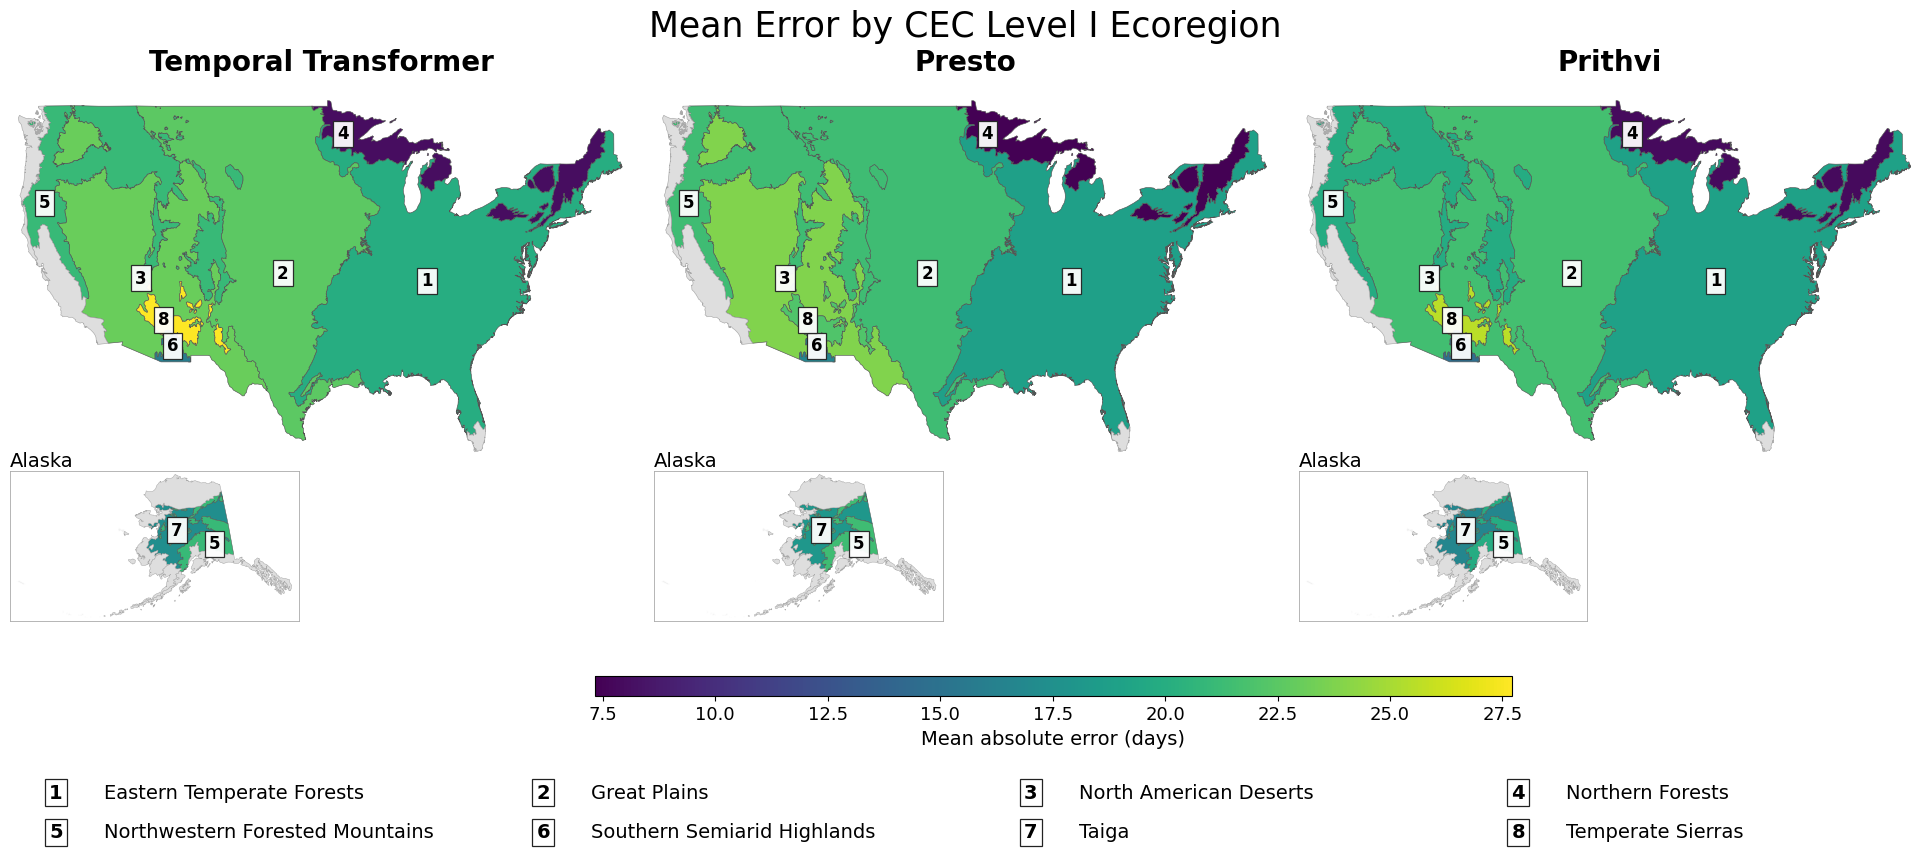

Saved: paper_latex/Images/ecoregion_mae_maps.pdf


In [3]:
regions = gpd.read_file(CACHE_DIR / "ecoregion_l1_us.geojson")
states = gpd.read_file(CACHE_DIR / "us_states.geojson")
all_values = eco_summary["mean"].to_numpy()
vmin, vmax = float(np.nanmin(all_values)), float(np.nanmax(all_values))
cmap = mpl.colormaps["viridis"]

represented_names = sorted(eco_summary["eco_region_name"].unique())
region_numbers = {name: i + 1 for i, name in enumerate(represented_names)}
conus_box = box(-125.5, 24.0, -66.0, 50.5)
alaska_box = box(-170, 51, -130, 72)

def representative_point_in(geometry, clip_box):
    valid_geometry = make_valid(geometry)
    clipped = valid_geometry if clip_box is None else valid_geometry.intersection(clip_box)
    if clipped.is_empty:
        return None
    parts = list(clipped.geoms) if hasattr(clipped, "geoms") else [clipped]
    polygon_parts = [part for part in parts if part.geom_type in {"Polygon", "MultiPolygon"}]
    if not polygon_parts:
        return None
    return max(polygon_parts, key=lambda part: part.area).representative_point()

def add_region_numbers(ax, panel, clip_box):
    for _, row in panel[panel["mean"].notna()].iterrows():
        point = representative_point_in(row.geometry, clip_box)
        if point is None:
            continue
        ax.text(
            point.x, point.y, str(region_numbers[row["eco_region_name"]]),
            ha="center", va="center", fontsize=12, fontweight="bold", zorder=10,
            bbox={"boxstyle": "square,pad=0.24", "facecolor": "white",
                  "edgecolor": "#222222", "linewidth": 0.9, "alpha": 0.94},
        )

fig = plt.figure(figsize=(19.5, 8.8))
grid = fig.add_gridspec(2, 3, height_ratios=[4.2, 1.65], hspace=0.01, wspace=0.035)
axes = [fig.add_subplot(grid[0, i]) for i in range(3)]
alaska_axes = [fig.add_subplot(grid[1, i]) for i in range(3)]
alaska_states = states[states["name"] == "Alaska"].to_crs("EPSG:3338")
ak_minx, ak_miny, ak_maxx, ak_maxy = alaska_states.total_bounds
ak_pad_x = 0.025 * (ak_maxx - ak_minx)
ak_pad_y = 0.025 * (ak_maxy - ak_miny)
ak_box_aspect = (ak_maxy - ak_miny + 2 * ak_pad_y) / (ak_maxx - ak_minx + 2 * ak_pad_x)

for ax, alaska_ax, model in zip(axes, alaska_axes, MODEL_ORDER):
    panel = regions.merge(
        eco_summary[eco_summary["model"] == model],
        left_on="id", right_on="eco_region_l1_id", how="left",
    )
    states.plot(ax=ax, facecolor="#f1f1f1", edgecolor="white", linewidth=0.5)
    panel.plot(
        ax=ax, column="mean", cmap=cmap, vmin=vmin, vmax=vmax,
        edgecolor="#555555", linewidth=0.45,
        missing_kwds={"color": "#dedede", "edgecolor": "#aaaaaa"},
    )
    ax.set_xlim(-125.5, -66.0)
    ax.set_ylim(24.0, 50.5)
    ax.set_aspect("auto")
    ax.set_axis_off()
    ax.set_title(MODEL_LABELS[model], fontsize=20, fontweight="bold", pad=10)
    add_region_numbers(ax, panel, conus_box)

    alaska_panel = panel.copy()
    alaska_panel["geometry"] = alaska_panel.geometry.map(
        lambda geometry: make_valid(geometry).intersection(alaska_box)
    )
    alaska_panel = alaska_panel[~alaska_panel.geometry.is_empty].to_crs("EPSG:3338")
    alaska_states.plot(ax=alaska_ax, facecolor="#f1f1f1", edgecolor="white", linewidth=0.35)
    alaska_panel.plot(
        ax=alaska_ax, column="mean", cmap=cmap, vmin=vmin, vmax=vmax,
        edgecolor="#555555", linewidth=0.35,
        missing_kwds={"color": "#dedede", "edgecolor": "#aaaaaa"},
    )
    alaska_ax.set_xlim(ak_minx - ak_pad_x, ak_maxx + ak_pad_x)
    alaska_ax.set_ylim(ak_miny - ak_pad_y, ak_maxy + ak_pad_y)
    alaska_ax.set_box_aspect(ak_box_aspect)
    alaska_ax.set_anchor("W")
    alaska_ax.set_xticks([]); alaska_ax.set_yticks([])
    alaska_ax.set_title("Alaska", fontsize=14, loc="left", pad=3)
    for spine in alaska_ax.spines.values():
        spine.set_edgecolor("#aaaaaa")
        spine.set_linewidth(0.6)
    add_region_numbers(alaska_ax, alaska_panel, None)

sm = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
cbar_ax = fig.add_axes([0.31, 0.205, 0.47, 0.023])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Mean absolute error (days)", fontsize=14, labelpad=4)
cbar.ax.tick_params(labelsize=13)

key_positions = [(0.03, 0.095), (0.28, 0.095), (0.53, 0.095), (0.78, 0.095),
                 (0.03, 0.050), (0.28, 0.050), (0.53, 0.050), (0.78, 0.050)]
for name, (x_pos, y_pos) in zip(represented_names, key_positions):
    number = region_numbers[name]
    fig.text(
        x_pos, y_pos, f"{number}", ha="left", va="center", fontsize=14, fontweight="bold",
        bbox={"boxstyle": "square,pad=0.21", "facecolor": "white",
              "edgecolor": "#222222", "linewidth": 0.9},
    )
    fig.text(x_pos + 0.028, y_pos, name.title(), ha="left", va="center", fontsize=14)

fig.suptitle("Mean Error by CEC Level I Ecoregion", fontsize=25, y=0.985)
fig.subplots_adjust(left=0.01, right=0.99, top=0.90, bottom=0.29)
eco_path = IMAGE_DIR / "ecoregion_mae_maps.pdf"
fig.savefig(eco_path, bbox_inches="tight", dpi=300)
plt.show()
print(f"Saved: {eco_path}")

## Analysis 2: Mean Error by NLCD Land-Cover Class

Annual NLCD 2019/2020 classes are aligned to each 30 m HLS grid using nearest-neighbor resampling. A tile/class estimate must contain at least **400 valid phase-pixel observations**, approximately 100 spatial pixels observed across four phases. A displayed class must occur in at least **three tile-years**. Alaska is absent because Annual NLCD used here covers CONUS only.

Bars show the mean of tile-year MAEs after equal seed averaging. Error bars are standard deviations across the three seeds.

In [4]:
land_raw = pd.read_csv(CACHE_DIR / "landcover_tile_mae.csv")
land_eligible = land_raw[land_raw["n_valid"] >= 400].copy()
class_support = (
    land_eligible.groupby(["landcover_id", "landcover_name"], as_index=False)
    .agg(n_tile_years=("tile_id", "nunique"), n_sites=("site_id", "nunique"))
)
keep_ids = class_support.loc[class_support["n_tile_years"] >= 3, "landcover_id"]
land_eligible = land_eligible[land_eligible["landcover_id"].isin(keep_ids)]

land_summary = summarize_seed_balanced(
    land_eligible, ["model", "landcover_id", "landcover_name"]
).drop(columns="n_tile_years").merge(
    class_support, on=["landcover_id", "landcover_name"], how="left"
)

display(
    land_summary.pivot(index=["landcover_name", "n_sites", "n_tile_years"],
                       columns="model", values="mean")
    .rename(columns=MODEL_LABELS).round(2)
)

,,model,Presto,Prithvi,Temporal Transformer
landcover_name,n_sites,n_tile_years,,,
Barren land,6,12,28.13,28.29,28.13
Cultivated crops,11,22,24.49,24.18,25.82
Deciduous forest,14,28,12.49,13.23,13.27
"Developed, high intensity",3,6,29.29,29.30,32.68
"Developed, low intensity",23,46,20.99,20.55,21.58
"Developed, medium intensity",11,22,24.62,23.11,24.99
"Developed, open space",22,43,20.88,20.64,21.24
Emergent herbaceous wetlands,13,26,16.44,16.49,17.37
Evergreen forest,17,34,21.15,21.13,22.01


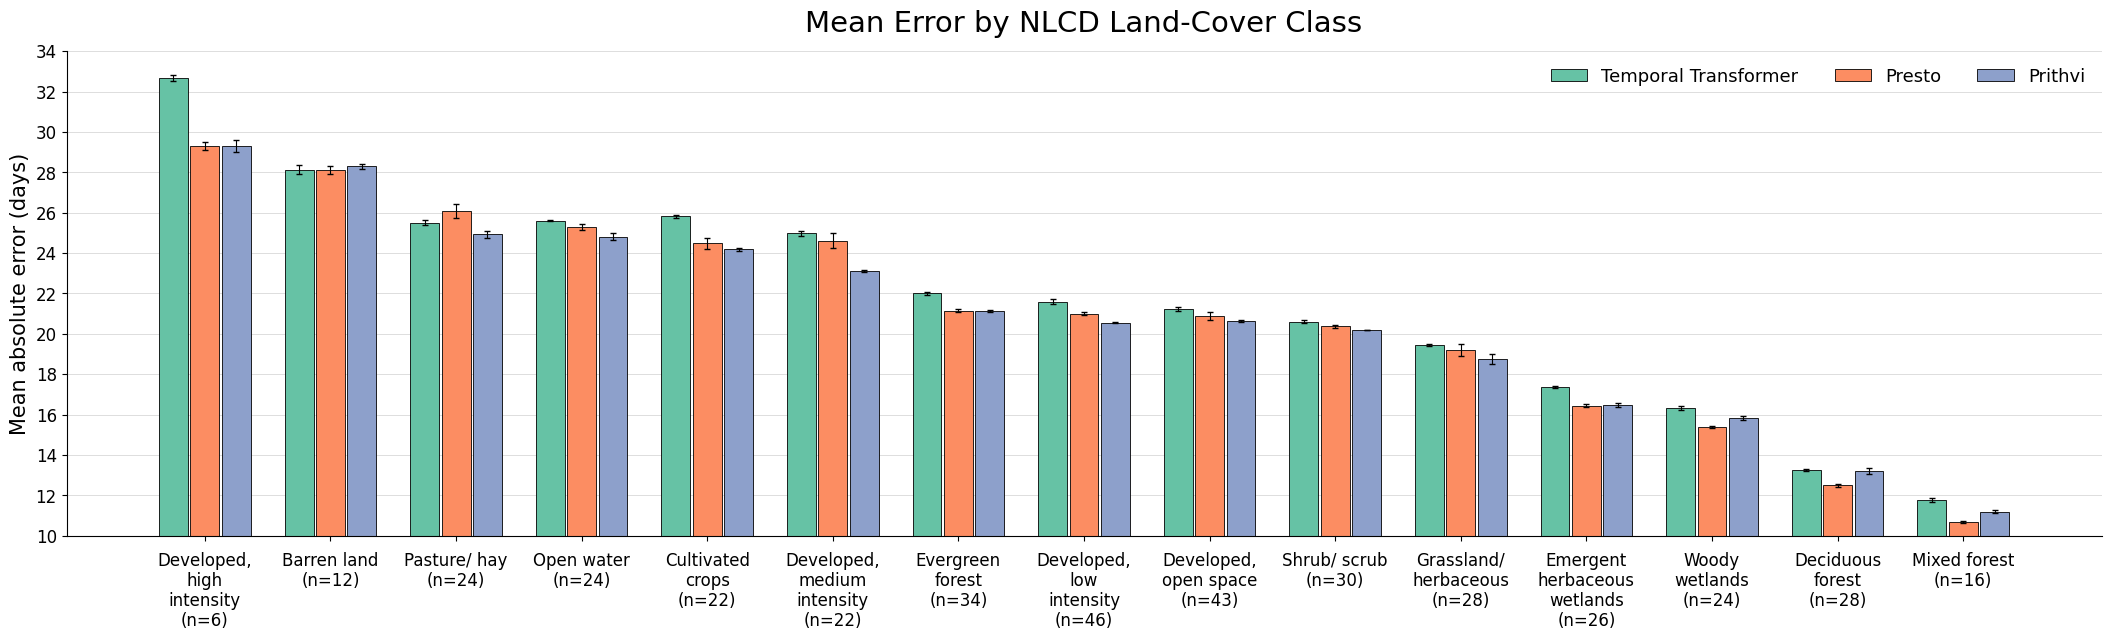

Saved: paper_latex/Images/landcover_mae.pdf


In [5]:
class_order = (
    land_summary.groupby(["landcover_id", "landcover_name"])["mean"].mean()
    .sort_values(ascending=False).index.tolist()
)

def wrap_landcover_label(name, n_tile_years, width=12):
    readable = name.replace("/", "/ ")
    lines = textwrap.wrap(
        readable, width=width, break_long_words=False, break_on_hyphens=False
    )
    return "\n".join(lines + [f"(n={n_tile_years})"])

labels = [
    wrap_landcover_label(
        name,
        int(class_support.loc[class_support["landcover_id"].eq(class_id), "n_tile_years"].iloc[0]),
    )
    for class_id, name in class_order
]
x = np.arange(len(class_order))
width = 0.25

lower_candidates = land_summary["mean"] - land_summary["seed_std"]
upper_candidates = land_summary["mean"] + land_summary["seed_std"]
y_min = max(0.0, np.floor(lower_candidates.min() - 0.5))
y_max = 2.0 * np.ceil((upper_candidates.max() + 1.0) / 2.0)

fig, ax = plt.subplots(figsize=(22, 9.5))

for offset, model in zip([-width, 0, width], MODEL_ORDER):
    indexed = land_summary[land_summary["model"] == model].set_index(["landcover_id", "landcover_name"])
    means = np.array([indexed.loc[key, "mean"] for key in class_order])
    stds = np.array([indexed.loc[key, "seed_std"] for key in class_order])
    ax.bar(
        x + offset, means - y_min, bottom=y_min, width=width * 0.92, yerr=stds,
        color=MODEL_COLORS[model], edgecolor="black", linewidth=0.6,
        error_kw={"linewidth": 0.8, "capsize": 2}, label=MODEL_LABELS[model],
    )

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12, linespacing=1.15)
ax.tick_params(axis="x", pad=8)
ax.tick_params(axis="y", labelsize=12)
ax.set_ylabel("Mean absolute error (days)", fontsize=15)
ax.set_title("Mean Error by NLCD Land-Cover Class", fontsize=21, pad=14)
ax.set_ylim(y_min, y_max)
ax.set_yticks(np.arange(y_min, y_max + 0.1, 2.0))
ax.grid(axis="y", color="#dddddd", linewidth=0.7)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(ncol=3, frameon=False, loc="upper right", fontsize=13)
fig.subplots_adjust(left=0.065, right=0.99, top=0.90, bottom=0.39)
land_path = IMAGE_DIR / "landcover_mae.pdf"
fig.savefig(land_path, bbox_inches="tight", dpi=300)
plt.show()
print(f"Saved: {land_path}")

## Analysis 3: Error by Ground-Truth Spatial Variation

Ground-truth spatial variation is measured robustly at multiple scales. For each phenophase, the median absolute DOY difference is calculated between valid horizontal and vertical pixel pairs at lags of 1, 2, 4, and 8 pixels. The four lag values are averaged, each phenophase is standardized across the 48 test tile-years, and the four standardized phase scores are averaged equally.

Tile-years are divided into equal-count tertiles of **16 tile-years each**. The map examples are the tile-year nearest the median score within each tertile; they are illustrative and do not determine the aggregate bars. Bars report tile-year-balanced MAE averaged over all four phenophases and then equally over seeds 42, 123, and 456. Error bars show standard deviation across seeds.

In [6]:
BIN_ORDER = ["Smoothest", "Intermediate", "Roughest"]
smooth_bins = pd.read_csv(SMOOTH_DIR / "gt_smoothness_tertiles.csv")
smooth_bins = smooth_bins[smooth_bins["metric"] == "robust_multiscale"].copy()
smooth_mae = pd.read_csv(SMOOTH_DIR / "mae_by_smoothness_tertile.csv")
smooth_mae = smooth_mae[smooth_mae["metric"] == "robust_multiscale"].copy()

assert smooth_bins.groupby("bin").size().reindex(BIN_ORDER).eq(16).all()
assert smooth_mae["n_seeds"].eq(3).all()

smooth_bins["valid_fraction"] = [
    np.load(TILE_DIR / f"{tile_id}.npz")["ground_truth_valid"].mean()
    for tile_id in smooth_bins["tile_id"]
]
bin_medians = smooth_bins.groupby("bin")["score"].median()
representatives = (
    smooth_bins[smooth_bins["valid_fraction"] >= 0.90]
    .assign(distance_from_bin_median=lambda frame:
            (frame["score"] - frame["bin"].map(bin_medians)).abs())
    .sort_values(["bin", "distance_from_bin_median", "tile_id"])
    .drop_duplicates("bin")
    .set_index("bin").reindex(BIN_ORDER)
)
# Use a nearly complete, visually legible intermediate example.
intermediate_example = smooth_bins.set_index("tile_id").loc["2019_WY-3_T12TWP"]
for column in ["site_id", "year", "score", "valid_fraction"]:
    representatives.loc["Intermediate", column] = intermediate_example[column]
representatives.loc["Intermediate", "tile_id"] = "2019_WY-3_T12TWP"

display(
    smooth_mae.pivot(index="bin", columns="model", values="mean_mae")
    .reindex(BIN_ORDER).rename(columns=MODEL_LABELS).round(2)
)
display(
    representatives[["tile_id", "score", "valid_fraction"]]
    .rename(columns={"score": "robust score"}).round(2)
)

model,Presto,Prithvi,Temporal Transformer
bin,,,
Smoothest,10.52,9.69,10.77
Intermediate,14.23,13.60,14.36
Roughest,20.86,21.55,22.25


,tile_id,robust score,valid_fraction
bin,,,
Smoothest,2020_WA-1_T11TMM,-0.83,0.99
Intermediate,2019_WY-3_T12TWP,-0.33,0.99
Roughest,2019_TX-1_T14RPV,0.83,0.97


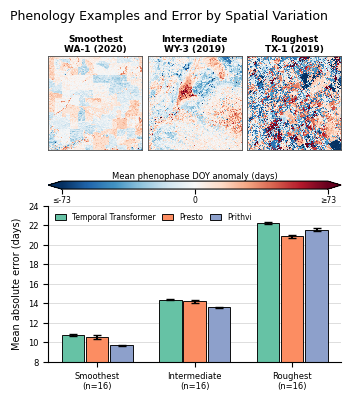

Saved: paper_latex/Images/spatial_variation_tertiles.pdf


In [7]:
phase_codes = ["G", "M", "S", "D"]
representative_tiles = {}
for bin_name in BIN_ORDER:
    tile_id = representatives.loc[bin_name, "tile_id"]
    tile = np.load(TILE_DIR / f"{tile_id}.npz")
    representative_tiles[bin_name] = {
        "tile_id": tile_id,
        "gt": tile["ground_truth_doy"],
        "valid": tile["ground_truth_valid"],
    }

# Center each map on its own median so color represents within-tile timing
# variation rather than differences in mean seasonal timing between sites.
cmap_phenology = plt.cm.RdBu_r.copy()
cmap_phenology.set_bad("0.85")
for item in representative_tiles.values():
    phase_stack = np.ma.array(item["gt"], mask=~item["valid"])
    item["mean_doy"] = phase_stack.mean(axis=0)
    item["doy_anomaly"] = item["mean_doy"] - np.ma.median(item["mean_doy"])

absolute_anomalies = np.concatenate([
    np.abs(item["doy_anomaly"].compressed()) for item in representative_tiles.values()
])
anomaly_limit = float(np.percentile(absolute_anomalies, 98))
vmin, vmax = -anomaly_limit, anomaly_limit

fig = plt.figure(figsize=(3.55, 3.85))
grid = fig.add_gridspec(
    4, 3, height_ratios=[1, 0.055, 0.035, 1.08],
    hspace=0.075, wspace=0.055,
)
image_axes = [fig.add_subplot(grid[0, col]) for col in range(3)]

for col, bin_name in enumerate(BIN_ORDER):
    item = representative_tiles[bin_name]
    ax = image_axes[col]
    image = ax.imshow(
        np.clip(item["doy_anomaly"], vmin, vmax), cmap=cmap_phenology,
        vmin=vmin, vmax=vmax, interpolation="nearest",
    )
    ax.set_xticks([]); ax.set_yticks([])
    year, site_id, _ = item["tile_id"].split("_", maxsplit=2)
    ax.set_title(f"{bin_name}\n{site_id} ({year})", fontsize=6.5, fontweight="bold", pad=3)
    for spine in ax.spines.values():
        spine.set_color("#555555")
        spine.set_linewidth(0.65)

cbar_ax = fig.add_subplot(grid[1, :])
cbar = fig.colorbar(image, cax=cbar_ax, orientation="horizontal", extend="both")
midpoint = (vmin + vmax) / 2
cbar.set_ticks([vmin, midpoint, vmax])
cbar.set_ticklabels([f"≤{vmin:.0f}", "0", f"≥{vmax:.0f}"])
cbar.ax.tick_params(labelsize=5.5, pad=1)
cbar.ax.set_title("Mean phenophase DOY anomaly (days)", fontsize=6, pad=2)

ax = fig.add_subplot(grid[3, :])
x = np.arange(len(BIN_ORDER))
width = 0.25
for offset, model in zip([-width, 0, width], MODEL_ORDER):
    indexed = smooth_mae[smooth_mae["model"] == model].set_index("bin").reindex(BIN_ORDER)
    ax.bar(
        x + offset, indexed["mean_mae"], width=width * 0.92,
        yerr=indexed["seed_std"], color=MODEL_COLORS[model],
        edgecolor="black", linewidth=0.65, capsize=3, label=MODEL_LABELS[model],
    )
ax.set_xticks(x)
ax.set_xticklabels([f"{name}\n(n=16)" for name in BIN_ORDER], fontsize=6)
ax.tick_params(axis="y", labelsize=6)
ax.set_ylabel("Mean absolute error (days)", fontsize=7)
ax.set_ylim(8, 24)
ax.set_yticks(np.arange(8, 25, 2))
ax.grid(axis="y", color="#dddddd", linewidth=0.7)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(ncol=3, frameon=False, loc="upper left", fontsize=5.5,
          handlelength=1.4, columnspacing=0.9)

fig.suptitle("Phenology Examples and Error by Spatial Variation", fontsize=9, y=0.995)
fig.subplots_adjust(left=0.16, right=0.985, top=0.94, bottom=0.08)
smooth_path = IMAGE_DIR / "spatial_variation_tertiles.pdf"
fig.savefig(smooth_path, bbox_inches="tight", dpi=300)
plt.show()
print(f"Saved: {smooth_path}")

## Interpretation Boundaries

- These are descriptive stratifications of 24 sites observed in two years, not estimates of performance over every US ecoregion or land-cover class.
- Seed variation captures training variability, while the number of independent geographic sites remains the main limitation for regional inference.
- Land-cover associations are not causal: class, geography, climate, target quality, and sample support are correlated.
- Spatial-variation tertiles are relative to this test set, and hard bin boundaries discard information. The continuous robust score should be used for formal association tests.
- The representative maps illustrate median-score tile-years; they are not averages and should not be interpreted as typical of every tile in a tertile.

In [8]:
expected_outputs = [eco_path, land_path, smooth_path]
for path in expected_outputs:
    assert path.exists() and path.stat().st_size > 1_000, f"Missing or empty figure: {path}"
print("All three paper-ready PDF figures were generated successfully.")

All three paper-ready PDF figures were generated successfully.
